In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sdes.plot as splt

# Load Results

In [2]:
filtering=True; smoothing=True; online_smoothing=True
remote = False

cdssm_spec_name = 'ts_mv_ou'
N=[100]; T=10; num=[10]; n_runs=100; i=20

if filtering:
    full_filtering_results = splt.load_results(cdssm_spec_name, 'f', N, T, num, n_runs, i)
if smoothing:
    full_smoothing_results = splt.load_results(cdssm_spec_name, 's', N, T, num, n_runs, i)
if online_smoothing:
    full_osmoothing_results = splt.load_results(cdssm_spec_name, 'os', N, T, num, n_runs, i)

In [3]:
fk_names = ['bootstrap', 'BsR_DH', 'guided', 'BwR_OU_OUP', 'BwR_DH_OUP', 'BwR_DH_IOUP', 'FwR_DH_OUP', 'FwR_DH_DBrP', 'FwR_DH_NDBBrP']

# Filtering

In [4]:
# Unpack the filtering results

filter_benchmark = full_filtering_results['benchmark_results'][0]['output'] # pf.summaries
multiSMC_results = full_filtering_results['multiSMC_results']
multicdssm_SMC_results = full_filtering_results['multiCDSSM_SMC_results']
filtering_results = multiSMC_results + multicdssm_SMC_results

cdssm = full_filtering_results['cdssm']
sde = cdssm.model_sde
x, y = full_filtering_results['x'], full_filtering_results['y']

# Extract the ending points 
idx = x[0].dtype.names[-1]
et_s = np.concatenate([x_path[idx] for x_path in x], axis=0).T # (dimX, T)
x0 = cdssm.x0; dimX = sde.dimX

In [5]:
filt_moms = filter_benchmark.moments

# Filtering moments
filt_means = np.stack([x0.ravel()] + [filt_mom['mean'] for filt_mom in filt_moms], axis=1) # (dimX, T+1)
filt_stds = np.sqrt(np.stack([x0.ravel()] + [filt_mom['var'] for filt_mom in filt_moms], axis=1))  # (dimX, T+1)
filt_logLts = np.array(filter_benchmark.logLts) # (T,)

# Visualisation of the CD-SSM:

## Filtering MSEs $X_t|Y_{1:t}$

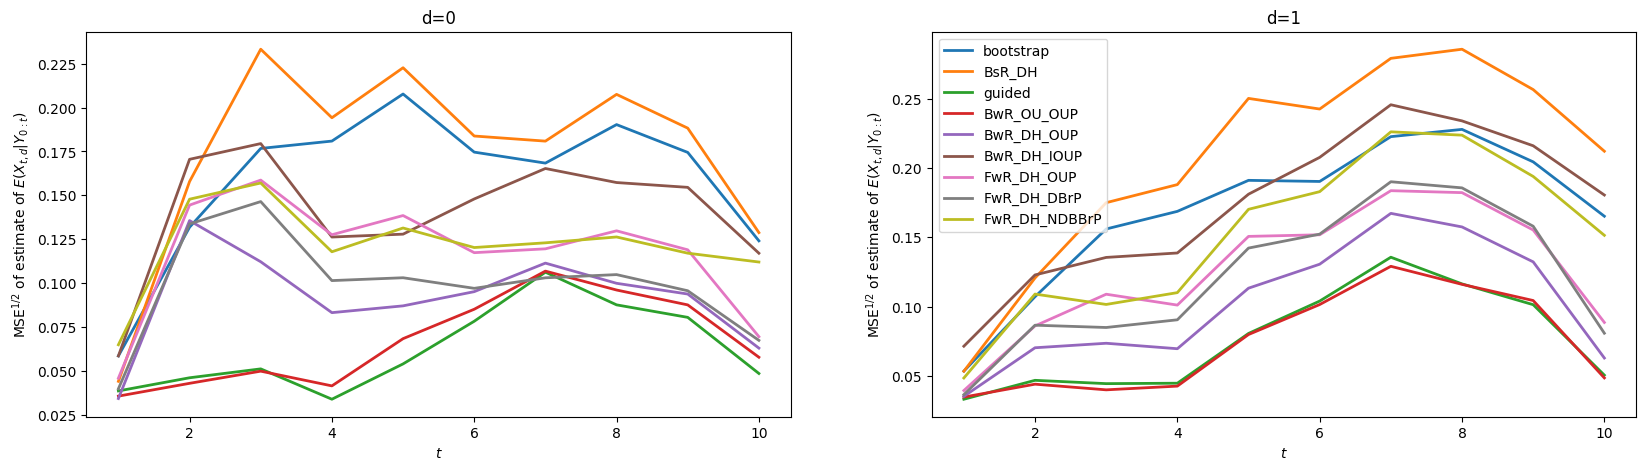

In [6]:
def filt_get_phi_x(r):
    return np.stack([mom['mean'] for mom in r['output'].moments], axis=1) # (dimX, T)

fig, axes = splt.mse_plot(filtering_results, fk_names, filt_means[:, 1:], filt_get_phi_x)
for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X_{t, d}|Y_{0:t})$')
    ax.set_title(f'd={i}')

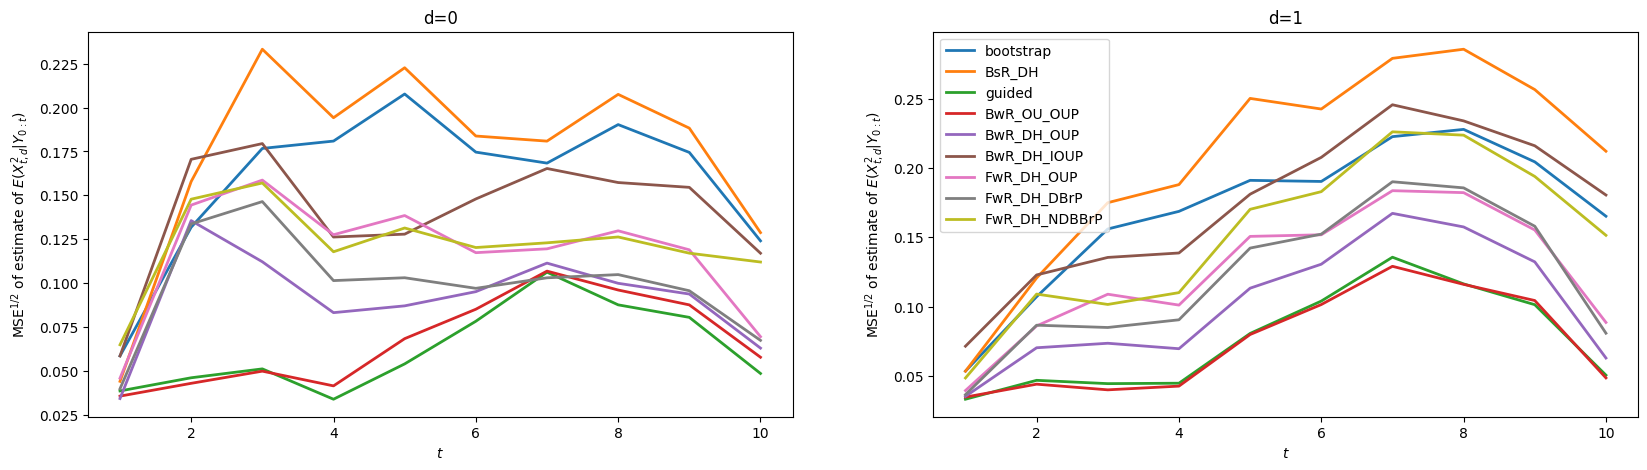

In [7]:
def filt_get_phi_phi_x(r):
    return np.stack([mom['mean'] for mom in r['output'].moments], axis=1) # (dimX, T)

fig, axes = splt.mse_plot(filtering_results, fk_names, filt_means[:, 1:], filt_get_phi_x)
for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X_{t, d}^2|Y_{0:t})$')
    ax.set_title(f'd={i}')

## Filtering MSEs: $\log(p(y_{0:t}))$

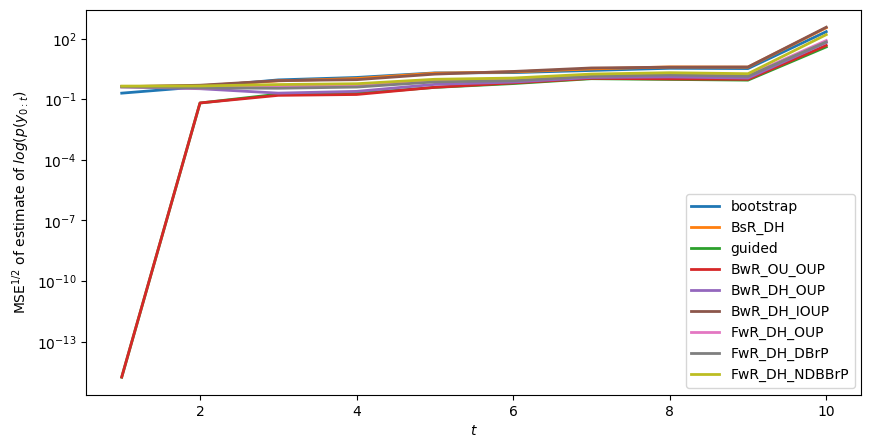

In [8]:
def get_logLt(r):
    return np.array(r['output'].logLts) # (T, )

fig, axes = splt.mse_plot(filtering_results, fk_names, filt_logLts, get_logLt)
axes.set_ylabel(r'MSE$^{1/2}$ of estimate of $log(p(y_{0:t})$')
axes.set_yscale('log')
plt.show()

# Filtering ESS Plot

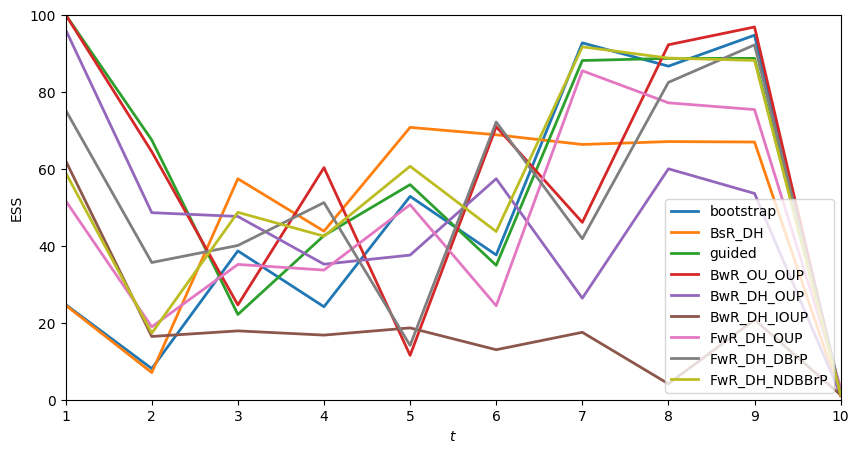

In [9]:
fig, axes = splt.ess_plot(filtering_results, fk_names)
fig.set_size_inches(10, 5)
plt.show()

# Offline Smoothing

In [10]:
# Unpack the smoothing results

smoother_benchmark = full_smoothing_results['benchmark_results'][0]['ests'] # dict of arrays
smc_smth_results = full_smoothing_results['multiSMC_results']
cdssm_smc_smth_results = full_smoothing_results['multiCDSSM_SMC_results']
smoothing_results = smc_smth_results + cdssm_smc_smth_results

x_smth, y_smth = full_smoothing_results['x'], full_smoothing_results['y']

# Verify that the data for the filtering and smoothing results is the same. 
assert np.all(np.isclose(np.concatenate([y_val for y_val in y], axis=0), np.concatenate([y_val for y_val in y_smth], axis=0)))

In [11]:
# Smoothing moments
smth_means = np.concatenate([x0, smoother_benchmark['phi_x']], axis=0).T # (dimX, T+1)
smth_vars = np.concatenate([np.zeros((1, dimX)), smoother_benchmark['phi_x_x'] - smoother_benchmark['phi_x']**2], axis=0).T # (dimX, T+1)
smth_stds = np.sqrt(smth_vars)


results_geneaology = [r for r in smoothing_results if r['method'] == 'geneaology']
results_FFBS_ON2 = [r for r in smoothing_results if r['method'] == 'FFBS_ON2']
results_FFBS_MCMC = [r for r in smoothing_results if r['method'] == 'FFBS_MCMC']

## Offline Smoothing MSEs - Geneaology $X_t|Y_{1:T}$

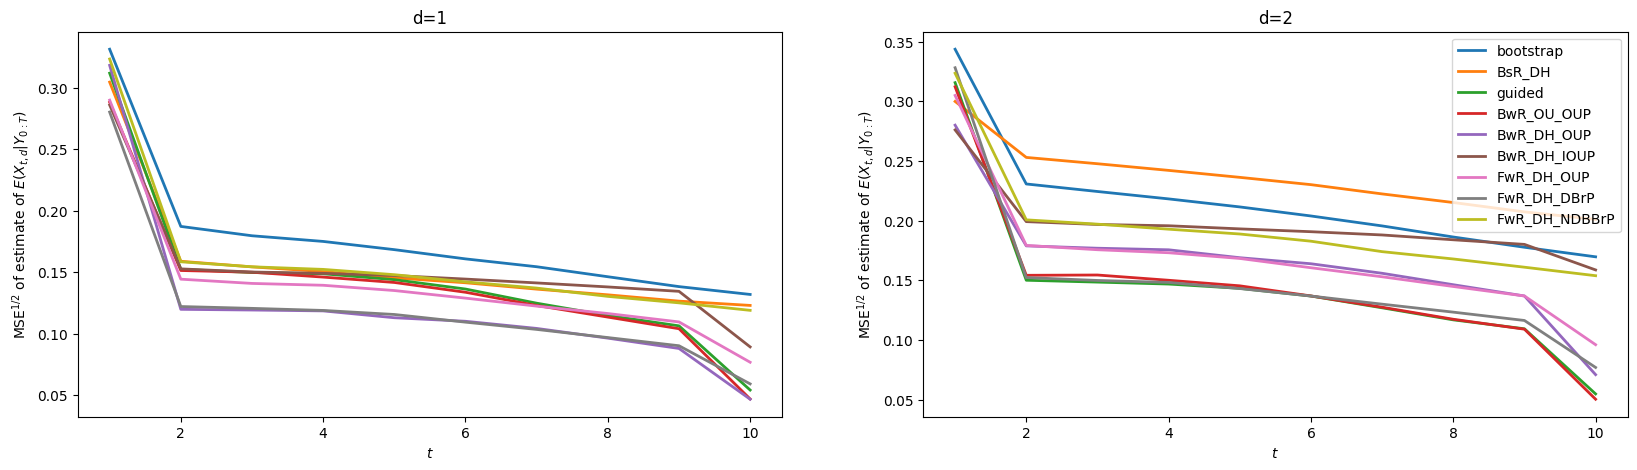

In [12]:
def smth_get_phi_x(r):
    return r['ests']['phi_x'].T # (dimX, T)

fig, axes = splt.mse_plot(results_geneaology, fk_names, smth_means[:, 1:], smth_get_phi_x)
for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X_{t, d}|Y_{0:T})$')
    ax.set_title(f'd={i+1}')

## Offline Smoothing MSEs - FFBS-MCMC $X_t|Y_{1:T}$

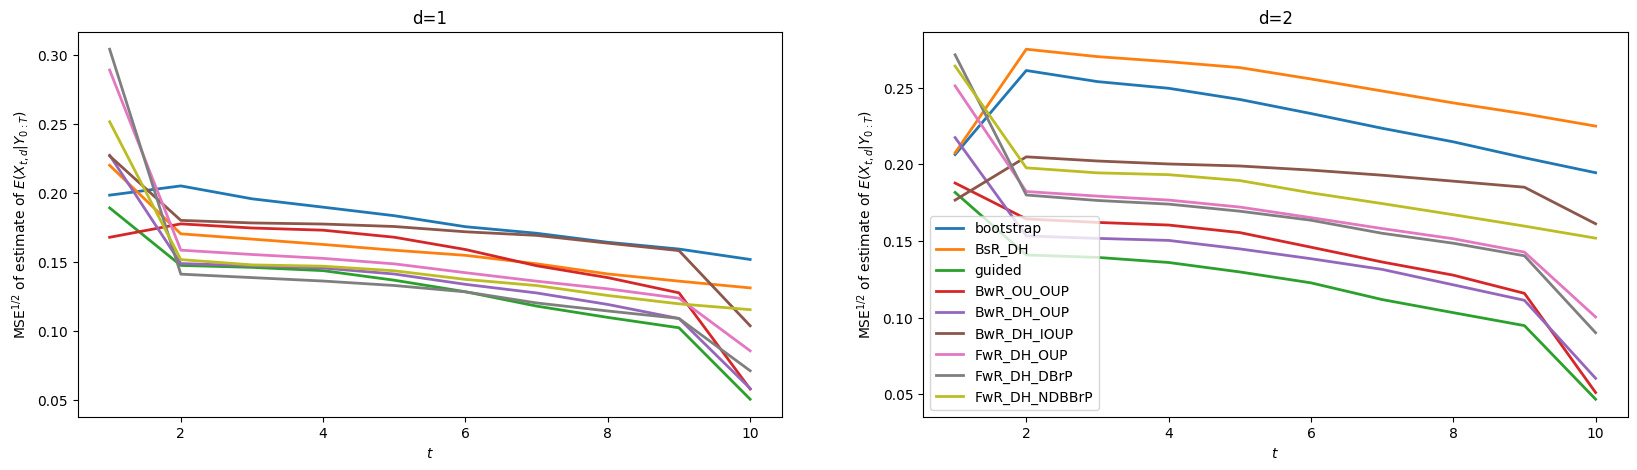

In [13]:
fig, axes = splt.mse_plot(results_FFBS_MCMC, fk_names, smth_means[:, 1:], smth_get_phi_x)
for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X_{t, d}|Y_{0:T})$')
    ax.set_title(f'd={i+1}')

## Offline Smoothing MSEs - FFBS $O(N^2)$

In [14]:
# fig, axes = splt.mse_plot(results_FFBS_ON2, fk_names, smth_means[:, 1:], smth_get_phi_x)
# for i, ax in enumerate(axes):
#     ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X_{t, d}|Y_{0:T})$')
#     ax.set_title(f'd={i+1}')

## Offline Smoothing MSEs - Geneaology $X^2_t|Y_{1:T}$

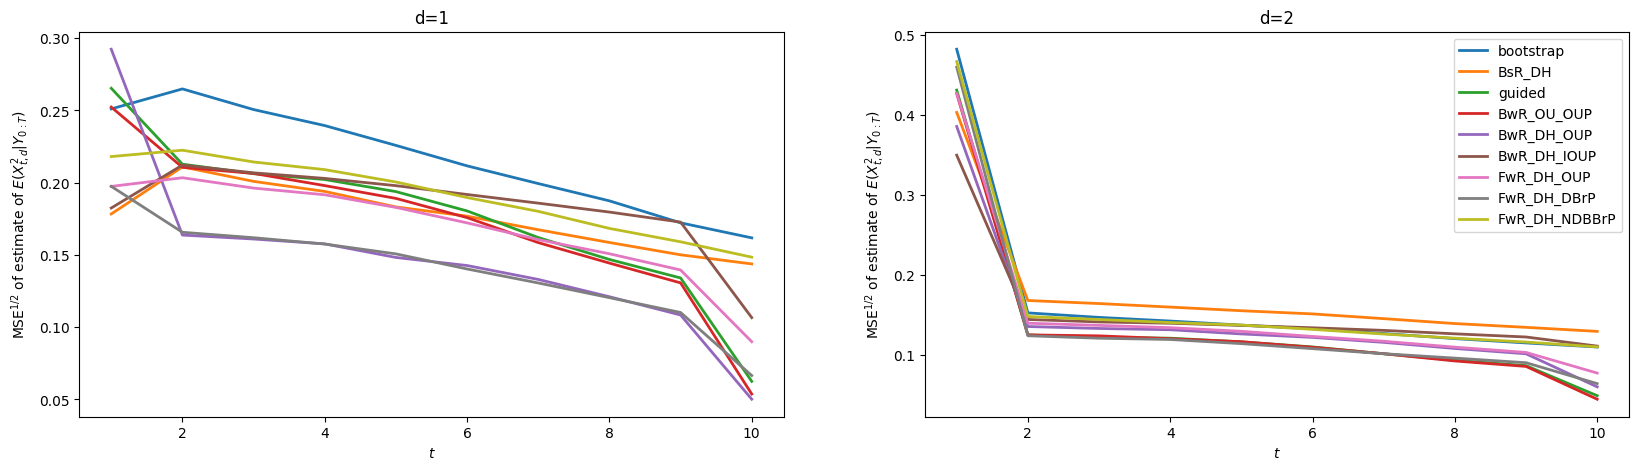

In [15]:
def smth_get_phi_x_x(r):
    return r['ests']['phi_x_x'].T # (dimX, T)

fig, axes = splt.mse_plot(results_geneaology, fk_names, smth_vars[:, 1:] + smth_means[:, 1:] ** 2, smth_get_phi_x_x)
for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X^2_{t, d}|Y_{0:T})$')
    ax.set_title(f'd={i+1}')

## Offline Smoothing MSEs - FFBS-MCMC $X^2_t|Y_{1:T}$

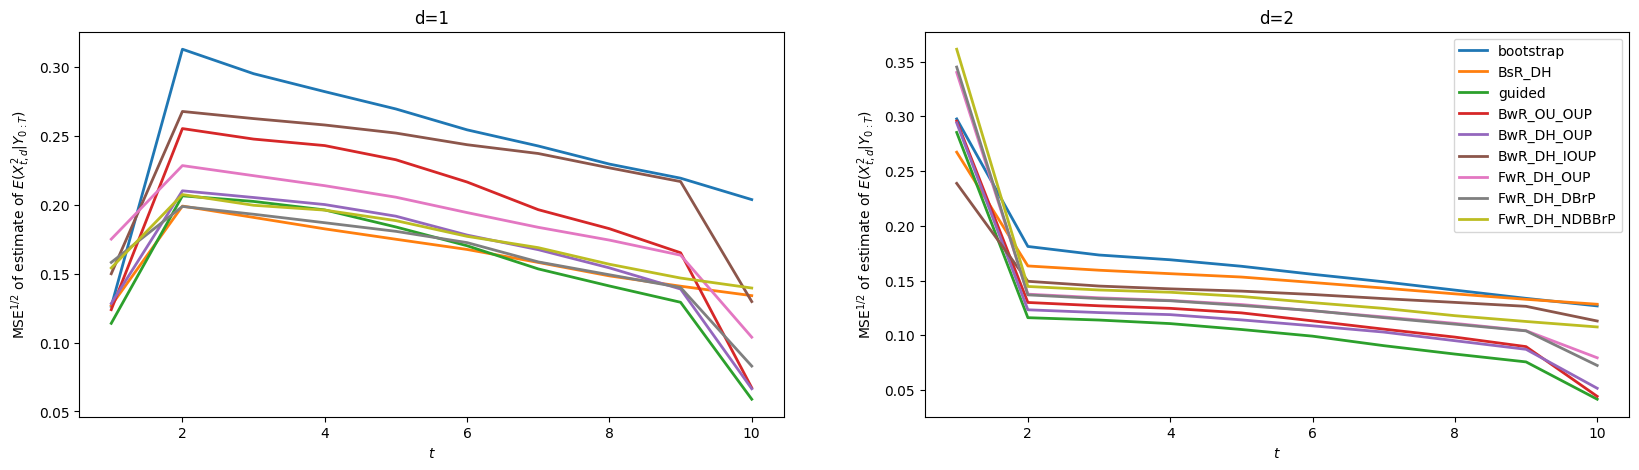

In [16]:
def smth_get_phi_x_x(r):
    return r['ests']['phi_x_x'].T # (dimX, T)

fig, axes = splt.mse_plot(results_FFBS_MCMC, fk_names, smth_vars[:, 1:] + smth_means[:, 1:] ** 2, smth_get_phi_x_x)
for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X^2_{t, d}|Y_{0:T})$')
    ax.set_title(f'd={i+1}')

## Offline Smoothing MSEs - FFBS $O(N^2)$

In [17]:
# fig, axes = splt.mse_plot(results_FFBS_ON2, fk_names, smth_vars[:, 1:] + smth_means[:, 1:] ** 2, smth_get_phi_x_x)
# for i, ax in enumerate(axes):
#     ax.set_ylabel(r'MSE$^{1/2}$ of estimate of $E(X^2_{t, d}|Y_{0:T})$')
#     ax.set_title(f'd={i+1}')

# Online Smoothing

In [18]:
# Unpack the online smoothing results

osmoother_benchmark = full_osmoothing_results['benchmark_results'][0]['ests'] # dict of arrays
smc_osmth_results = full_osmoothing_results['multiSMC_results']
cdssm_smc_osmth_results = full_osmoothing_results['multiCDSSM_SMC_results']
osmoothing_results = smc_osmth_results + cdssm_smc_osmth_results

x_smth, y_smth = full_osmoothing_results['x'], full_osmoothing_results['y']

# Verify that the data for the filtering and online smoothing results is the same. 
assert np.all(np.isclose(np.concatenate([y_val for y_val in y], axis=0), np.concatenate([y_val for y_val in y_smth], axis=0)))

In [19]:
results_add_naive = [r for r in osmoothing_results if r['col'] == 'MultiOnline_smooth_naive']
results_add_0N2 = [r for r in osmoothing_results if r['col'] == 'MultiOnline_smooth_ON2']
results_add_mcmc = [r for r in osmoothing_results if r['col'] == 'MultiOnline_smooth_mcmc']

## Online Smoothing MSEs - Geneaology Tracking

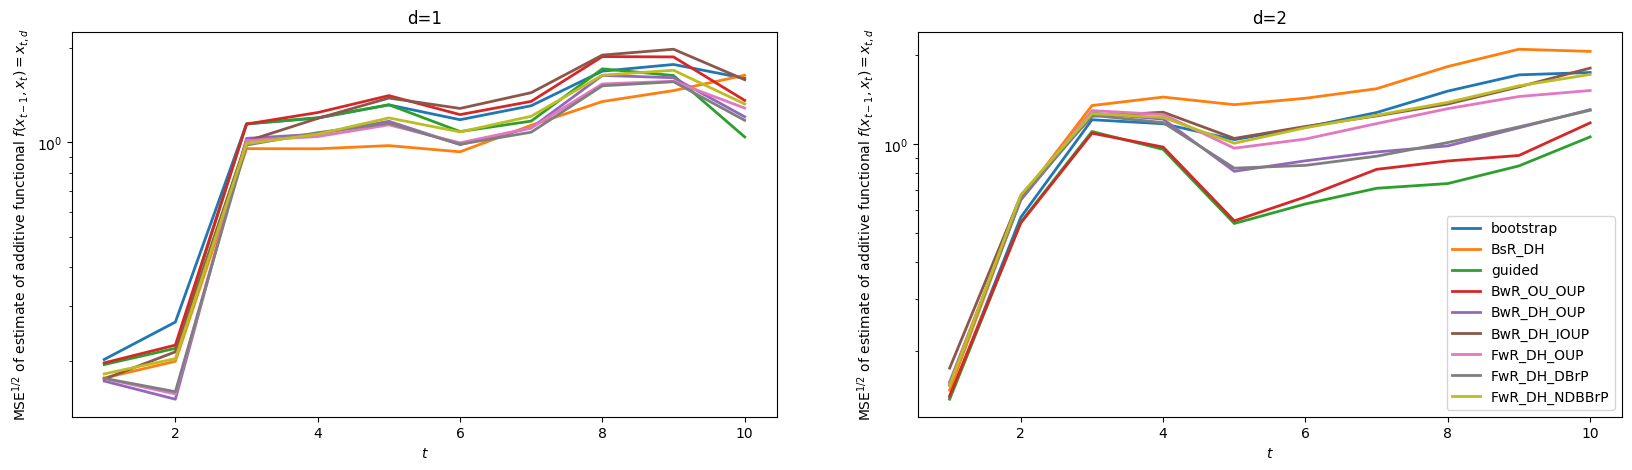

In [20]:
def osmth_get_phi_x(r):
    ests = getattr(r['output'], 'multiOnline_smooth_naive')
    return np.stack([est['phi_x'] for est in ests], axis=1) # (dimX, T)

fig, axes = splt.mse_plot(results_add_naive, fk_names, osmoother_benchmark['phi_x'].T, osmth_get_phi_x)

for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of additive functional $f(x_{t-1}, x_{t}) = x_{t, d}$')
    ax.set_title(f'd={i+1}')
    ax.set_yscale('log')

## Online Smoothing MSEs - Forward Additive-MCMC 

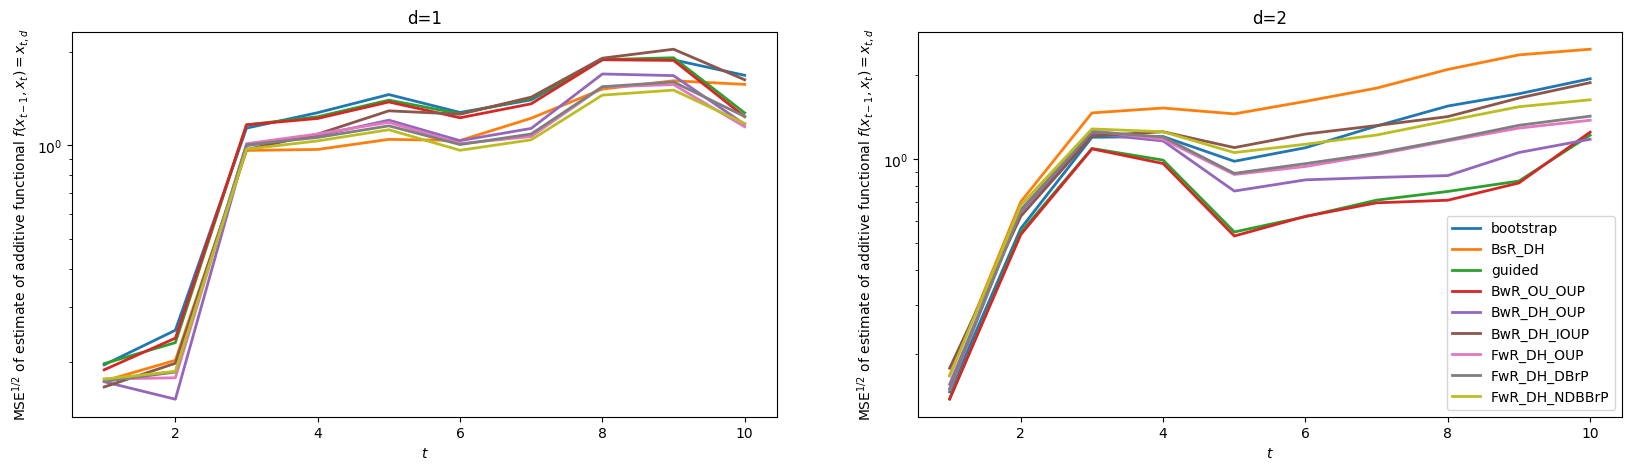

In [21]:
def osmth_get_phi_x(r):
    ests = getattr(r['output'], 'multiOnline_smooth_mcmc')
    return np.stack([est['phi_x'] for est in ests], axis=1) # (dimX, T)

fig, axes = splt.mse_plot(results_add_mcmc, fk_names, osmoother_benchmark['phi_x'].T, osmth_get_phi_x)

for i, ax in enumerate(axes):
    ax.set_ylabel(r'MSE$^{1/2}$ of estimate of additive functional $f(x_{t-1}, x_{t}) = x_{t, d}$')
    ax.set_title(f'd={i+1}')
    ax.set_yscale('log')

## Online Smoothing MSEs - Forward Additive-$\mathcal{O}(N^2)$ 

In [22]:
# def osmth_get_phi_x(r):
#     ests = getattr(r['output'], 'multiOnline_smooth_ON2')
#     return np.stack([est['phi_x'] for est in ests], axis=1) # (dimX, T)

# fig, axes = splt.mse_plot(results_add_0N2, fk_names, osmoother_benchmark['phi_x'].T, osmth_get_phi_x)

# for i, ax in enumerate(axes):
#     ax.set_ylabel(r'MSE$^{1/2}$ of estimate of additive functional $f(x_{t-1}, x_{t}) = x_{t, d}$')
#     ax.set_title(f'd={i+1}')
#     ax.set_yscale('log')

# Filtering Boxplots 

### CPU Times

In [23]:
# fig, axes = splt.boxplots(filtering_results, [splt.filt_cpu_time], fk_names)
# fig.set_size_inches(20, 5)
# plt.show()

### LogLts

In [24]:
# times = [0, 1, 2, 8, 9]
# logLts = np.array(benchmark_filter.summaries.logLts)
# fig, axes = splt.boxplots(filtering_results, splt.gen_logLt_funcs(times), fk_names, true_values=logLts[times])
# fig.set_size_inches(20, 15)
# plt.show()

### Filtering Means

In [25]:
# filt_mean_mom_funcs = splt.gen_mom_funcs(splt.filt_mean, times, dimX=2)
# fig, axes = splt.boxplots(filtering_results, filt_mean_mom_funcs[0], fk_names, true_values=filt_means[:, 1:][0, times])
# fig.set_size_inches(25, 15)
# plt.show()

In [26]:
# fig, axes = splt.boxplots(filtering_results, filt_mean_mom_funcs[1], fk_names, true_values=filt_means[:, 1:][1, times])
# fig.set_size_inches(25, 15)
# plt.show()

<!-- # Offline Smoothing Boxplots -->

<!-- ## Boxplots: FFBS MCMC -->

<!-- ### CPU Times -->

In [27]:
# times = [1, 2, 8]
# fig, axes = splt.boxplots(results_FFBS_MCMC, [splt.smth_cpu_time], fk_names)
# fig.set_size_inches(20, 5)
# plt.show()

<!-- ### Smoothing Means  -->

In [28]:
# smth_mean_mom_funcs = splt.gen_mom_funcs(splt.smth_mean, times, dimX=2)
# fig, axes = splt.boxplots(results_FFBS_MCMC, smth_mean_mom_funcs[0], fk_names, true_values=smth_means[:, 1:][0, times])
# fig.set_size_inches(15, 15)
# plt.show()

In [29]:
# fig, axes = splt.boxplots(results_FFBS_MCMC, smth_mean_mom_funcs[1], fk_names, true_values=smth_means[:, 1:][1, times])
# fig.set_size_inches(15, 15)
# # plt.show()

## Boxplots - FFBS $\mathcal{O}(N^2)$

### CPU Times

In [30]:
# times = [0, 4, 8]
# fig, axes = splt.boxplots(results_FFBS_ON2, [splt.smth_cpu_time], fk_names)
# fig.set_size_inches(15, 5)
# plt.show()

### Smoothing means

In [31]:
# # times = [0, 4, -1]
# smth_mean_mom_funcs = splt.gen_mom_funcs(splt.smth_mean, times, dimX=2)
# fig, axes = splt.boxplots(results_FFBS_ON2, smth_mean_mom_funcs[0], fk_names, true_values=smth_means[:, 1:][0, times])
# fig.set_size_inches(20, 15)
# plt.show()

In [32]:
# # times = [0, 4, -1]
# smth_mean_mom_funcs = splt.gen_mom_funcs(splt.smth_mean, times, dimX=2)
# fig, axes = splt.boxplots(results_FFBS_ON2, smth_mean_mom_funcs[1], fk_names, true_values=smth_means[:, 1:][1, times])
# fig.set_size_inches(20, 15)
# plt.show()

## Scrap Code: Plot of TS_MV_OU 

In [33]:
def make_plot(filt_smth_means, filt_smth_stds):
    """
    Plot used in the MV_OU_process_smoothing.ipynb notebook.
    Put here to make the notebook cleaner.
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))

    for l, title in enumerate(['filtering', 'smoothing']):
        for i in range(dimX):
            axes[l,i].plot(s, x_arr[i], label=f'$X_{i}(s)$ - Time inhomogeneous OU process')
            axes[l,i].plot(ts[1:], et_s[i], 'o', c='#1f77b4', markersize=5., label='$e_t$')
            axes[l,i].plot(ts[1:-1], y_arr[i, :-1], 'x', markersize=10., label='$y_t: \eta=0.4$')
            axes[l,i].plot(ts[-1:], y_arr[i, -1:],'x', markersize=10., c='r', label='$y_t: \eta=0.01$')
            axes[l,i].set_xlabel(r'$t$')
            axes[l,i].set_ylabel(ylabels[i])
            axes[l,i].set_title(f'{title} distribution: $x_{i+1}$')

            for j in range(T+1):
                axes[l,i].axvline(x=j, color='black', linestyle='--', alpha=0.3, linewidth=1)
            axes[l,i].set_xticks([k for k in range(T+1)])

            axes[l,i].plot(ts, filt_smth_means[l][i], c='g', alpha=0.3, label='mean $\mu_t$')
            axes[l,i].plot(ts, filt_smth_means[l][i] + 2*filt_smth_stds[l][i], '--', c='g', alpha=0.3, label='$\mu_t$ +/- 2$\sigma_t$')
            axes[l,i].plot(ts, filt_smth_means[l][i] - 2*filt_smth_stds[l][i], '--', c='g', alpha=0.3)


    fig.suptitle(f'Time-switching MvOU process with switching time at t={t_switch} and t={t_switchY}')
    plt.legend()
    return fig, axes

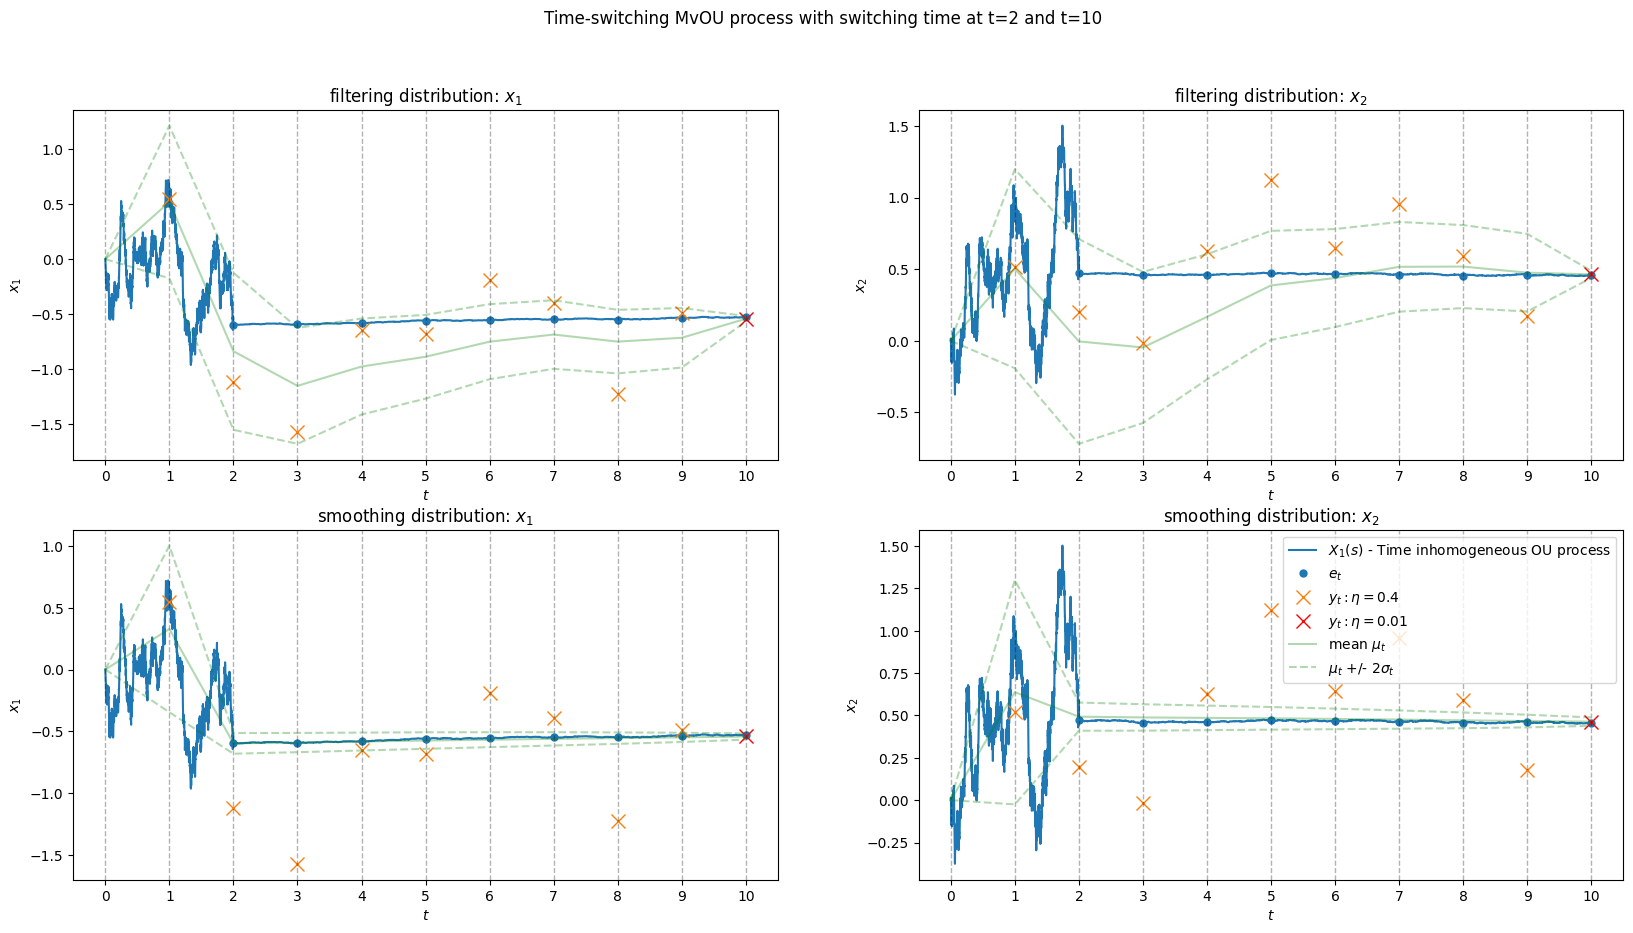

In [34]:
if cdssm_spec_name == 'ts_mv_ou':
    
    
    
    delta_s = cdssm.delta_s; s_T = T*delta_s; x0 = cdssm.x0
    t_switch = cdssm.t_switch; t_switchY = cdssm.t_switchY
    dimX = cdssm.model_sde.dimX

    s = np.linspace(0, s_T, num=T*1000+1) # (T*1000+1,)
    ts = np.arange(0, T+1, dtype=np.float64)*delta_s # (T+1,)
    sa_to_arr = lambda x: np.concatenate([x[name] for name in x.dtype.names], axis=0) # (num, dimX)
    x_arr = np.concatenate([x0] + [sa_to_arr(x_t) for x_t in x], axis=0).T # (dimX, 1 + T*num)
    y_arr = np.concatenate([y_t for y_t in y]).T # (dimX, T)
    ylabels = [r'$x_1$', r'$x_2$']

    filt_smth_means = [filt_means, smth_means]; filt_smth_stds = [filt_stds, smth_stds]
    make_plot(filt_smth_means, filt_smth_stds)
    plt.show()

# Scrap Code: Single Run of Smoothers

In [35]:
import particles.state_space_models as ssms
from particles.core import SMC
from sdes.smoothing import add_hist_methods
import sdes.feynman_kac as sfk
N = 320
# discrete_ssm = cdssm.discrete_ssm()
# fk = ssms.GuidedPF(ssm=discrete_ssm, data=y)
# smc = SMC(fk=fk, N=N, store_history=True, ESSrmin=1.)
# smc.run()

fk = sfk.ForwardReparameterisedDA(cdssm=cdssm, data=y, proposal_sde_cls=MvOUProposal, auxiliary_bridge_cls=MvDelyonHuAuxBridge)
smc = CDSSM_SMC(fk=fk, N=N, store_history=True, ESSrmin=1.)
smc.run()
add_hist_methods(smc.hist)


method_dict = {"geneaology": 'backward_sampling_geneaology',
               "FFBS_ON2": 'backward_sampling_ON2',
               "FFBS_MCMC": 'backward_sampling_mcmc'
               }
backward_samples_dict = {method: getattr(smc.hist, method_dict[method])(N) for method in method_dict.keys()}


NameError: name 'MvOUProposal' is not defined

In [ ]:
idx = smc.hist._init_backward_sampling(N)
idx_gene = smc.hist.backward_sampling_geneaology_idx(N, idx=idx)
idx_ON2 = smc.hist.backward_sampling_ON2_idx(N, idx=idx)
idx_mcmc = smc.hist.backward_sampling_mcmc_idx(N, idx=idx)

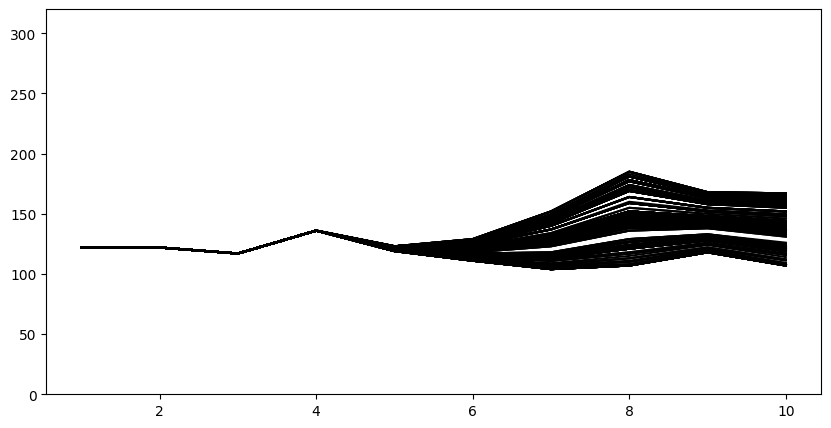

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.ylim(0, N)
times = np.arange(1, T+1)
for i in range(N):
    plt.plot(times, idx_gene[:, i], c='black')
plt.show()

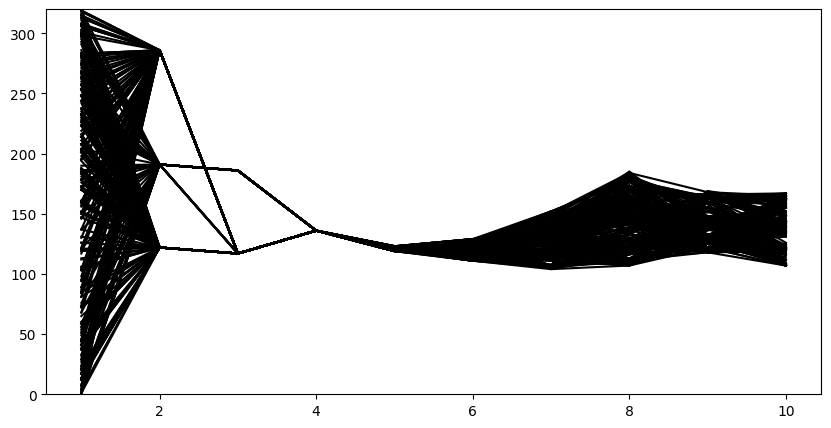

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.ylim(0, N)
times = np.arange(1, T+1)
for i in range(N):
    plt.plot(times, idx_ON2[:, i], c='black')
plt.show()

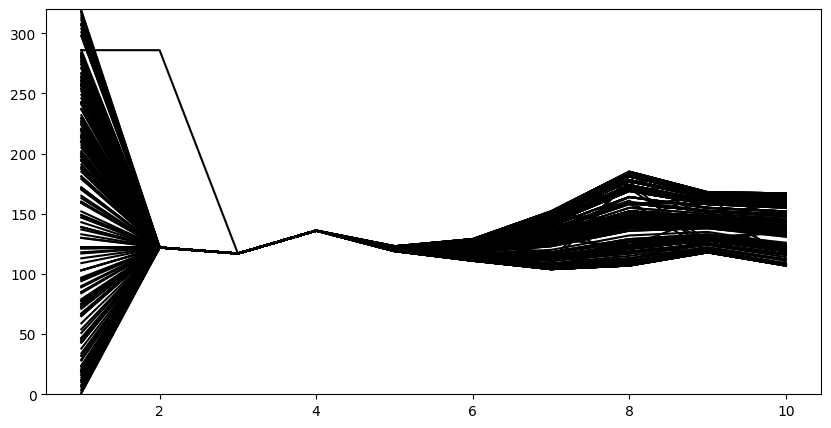

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.ylim(0, N)
times = np.arange(1, T+1)
for i in range(N):
    plt.plot(times, idx_mcmc[:, i], c='black')
plt.show()

# DataFrame stuff

In [ ]:
smoothing_results[0]['ests']['phi_x'][0]

array([0.69134827, 1.14853893])

In [ ]:
keys = ['run', 'method', 'N', 'fk', 'seed', 'cpu']
data = {**{k: [] for k in keys}, 'est': [], 'true': []}

for res in smoothing_results:
    for k in keys:
        data[k].append(res[k])
    data['est'].append(res['ests']['phi_x'][0][1])

data['true'] = [smoother_benchmark['phi_x'][0][1]] * len(data['est'])
df = pd.DataFrame(data)
df['error'] = df['est'] - df['true']
df['sq_error'] = df['error']**2

groupby = df.groupby(['method', 'N', 'fk'])
mses = groupby['sq_error'].mean().reset_index()
mses['rmse'] = np.sqrt(mses['sq_error'])

In [ ]:
cpus = groupby['cpu'].sum().reset_index()
cpus[cpus['fk'] == 'BwR_DH_OUP']

,method,N,fk,cpu
2,FFBS_MCMC,20,BwR_DH_OUP,1.470072
11,FFBS_MCMC,40,BwR_DH_OUP,1.950672
20,FFBS_MCMC,80,BwR_DH_OUP,2.831378
29,FFBS_MCMC,160,BwR_DH_OUP,4.535418
38,FFBS_MCMC,320,BwR_DH_OUP,7.418523
47,FFBS_ON2,20,BwR_DH_OUP,7.220609
56,FFBS_ON2,40,BwR_DH_OUP,18.404697
65,FFBS_ON2,80,BwR_DH_OUP,55.116106
74,FFBS_ON2,160,BwR_DH_OUP,182.635960
83,FFBS_ON2,320,BwR_DH_OUP,652.159859


In [ ]:
N=[20, 40, 640, 1280, 2560]

,method,N,fk,sq_error,rmse
8,FFBS_MCMC,20,guided,0.036615,0.191351
17,FFBS_MCMC,40,guided,0.024296,0.155873
26,FFBS_MCMC,80,guided,0.028841,0.169826
35,FFBS_MCMC,160,guided,0.019998,0.141415
44,FFBS_MCMC,320,guided,0.026279,0.162107
53,FFBS_ON2,20,guided,0.016999,0.130381
62,FFBS_ON2,40,guided,0.005824,0.076315
71,FFBS_ON2,80,guided,0.003362,0.057985
80,FFBS_ON2,160,guided,0.002498,0.049981
89,FFBS_ON2,320,guided,0.000775,0.027831


<Axes: xlabel='N'>

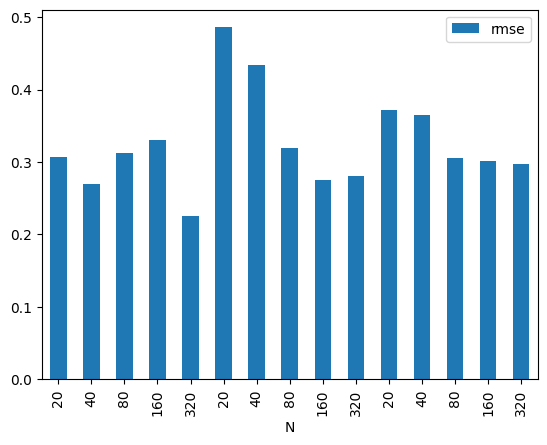

In [ ]:
mses[(mses['fk'] == 'FwR_DH_OUP')].plot(x='N', y='rmse', kind='bar')

In [ ]:
mses

,method,N,fk,sq_error,rmse
0,FFBS_MCMC,20,BsR_DH,0.054042,0.232470
1,FFBS_MCMC,20,BwR_DH_IOUP,0.046443,0.215505
2,FFBS_MCMC,20,BwR_DH_OUP,0.035050,0.187217
3,FFBS_MCMC,20,BwR_OU_OUP,0.034310,0.185229
4,FFBS_MCMC,20,FwR_DH_DBrP,0.084992,0.291533
...,...,...,...,...,...
130,geneaology,320,FwR_DH_DBrP,0.097385,0.312065
131,geneaology,320,FwR_DH_NDBBrP,0.107631,0.328072
132,geneaology,320,FwR_DH_OUP,0.088107,0.296828
133,geneaology,320,bootstrap,0.094577,0.307534


In [ ]:
df[['N', 'method', 'cpu']].groupby(['N', 'method']).sum()

cpu
N   method                  
20  FFBS_MCMC      24.650613
    FFBS_ON2      150.386523
    geneaology     10.687249
40  FFBS_MCMC      35.538406
    FFBS_ON2      432.083559
    geneaology     15.116766
80  FFBS_MCMC      57.671030
    FFBS_ON2     1408.344303
    geneaology     23.985542
160 FFBS_MCMC      99.257458
    FFBS_ON2     4977.574894
    geneaology     41.508735
320 FFBS_MCMC     177.475659
    FFBS_ON2    18411.609785
    geneaology     73.674328

In [ ]:
df[df['fk']=='guided']

,run,method,N,fk,seed,cpu,est,true,error,sq_error
1,0,geneaology,20,guided,3701145,0.003810,0.422828,0.637636,-0.214807,0.046142
3,0,geneaology,40,guided,10965555,0.004602,0.541540,0.637636,-0.096096,0.009234
5,0,geneaology,80,guided,17131483,0.006563,0.773612,0.637636,0.135976,0.018489
7,0,geneaology,160,guided,21684869,0.010274,1.078173,0.637636,0.440538,0.194074
9,0,geneaology,320,guided,28000582,0.017502,0.922166,0.637636,0.284530,0.080958
...,...,...,...,...,...,...,...,...,...,...
1491,49,FFBS_MCMC,20,guided,4269365890,0.004674,0.494841,0.637636,-0.142795,0.020390
1493,49,FFBS_MCMC,40,guided,4277334622,0.005582,0.709357,0.637636,0.071722,0.005144
1495,49,FFBS_MCMC,80,guided,4282978648,0.007560,0.727946,0.637636,0.090311,0.008156
1497,49,FFBS_MCMC,160,guided,4287538506,0.011346,0.606340,0.637636,-0.031296,0.000979
